# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

subscriptions = pd.read_csv('./ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('./ravenstack_feature_usage.csv')

print(subscriptions.shape, feature_usage.shape)
display(subscriptions.head())
display(feature_usage.head())

print(subscriptions.dtypes)
print(subscriptions.isna().sum())
print(feature_usage.dtypes)
print(feature_usage.isna().sum())

subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

print('구독 ID 고유 개수:', subscriptions['subscription_id'].nunique())
print('기능 사용 이벤트 행 수:', len(feature_usage))
print('usage_id 중복 개수:', feature_usage['usage_id'].duplicated().sum())


(5000, 14) (25000, 8)
subscription_id       object
account_id             object
start_date             object
end_date               object
plan_tier              object
seats                   int64
mrr_amount              int64
arr_amount              int64
is_trial                 bool
upgrade_flag              bool
downgrade_flag            bool
churn_flag                bool
billing_frequency       object
auto_renew_flag           bool
dtype: object
subscription_id          0
account_id               0
start_date               0
end_date              4514
plan_tier                0
seats                    0
mrr_amount               0
arr_amount               0
is_trial                 0
upgrade_flag             0
downgrade_flag           0
churn_flag                0
billing_frequency        0
auto_renew_flag           0
dtype: int64
usage_id                object
subscription_id         object
usage_date              object
feature_name            object
usage_count            

---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

      stage  subscriptions  conversion_rate  churn_rate  dropped
0     구독 시작           5000              NaN         NaN      NaN
1     기능 사용           4967         0.993400    0.006600     33.0
2     유료 구독           4193         0.844172    0.155828    774.0
3  현재 유료 유지           3788         0.903410    0.096590    405.0


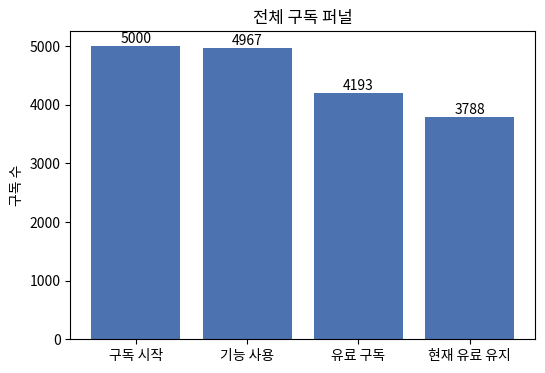

In [ ]:
# 1) 전체 구독 ID
started_ids = set(subscriptions['subscription_id'])

# 2) 기능 사용 기록이 있는 구독 ID (started_ids와 교집합)
used_sub_ids = set(feature_usage['subscription_id'].unique())
used_ids = used_sub_ids & started_ids

# 3) used_ids 중에서 trial이 아닌 구독
trial_false_ids = set(subscriptions.loc[subscriptions['is_trial'] == False, 'subscription_id'])
paid_ids = used_ids & trial_false_ids

# 4) paid_ids 중에서 아직 안 끝난(end_date가 없는) 구독
no_end_ids = set(subscriptions.loc[subscriptions['end_date'].isna(), 'subscription_id'])
retained_paid_ids = paid_ids & no_end_ids

funnel = pd.DataFrame({
    'stage': ['구독 시작', '기능 사용', '유료 구독', '현재 유료 유지'],
    'subscriptions': [len(started_ids), len(used_ids), len(paid_ids), len(retained_paid_ids)]
})

funnel['conversion_rate'] = funnel['subscriptions'] / funnel['subscriptions'].shift(1)
funnel['churn_rate'] = 1 - funnel['conversion_rate']
funnel['dropped'] = (funnel['subscriptions'].shift(1) - funnel['subscriptions'])

print(funnel)

plt.figure(figsize=(6,4))
plt.bar(funnel['stage'], funnel['subscriptions'], color='#4C72B0')
for i, v in enumerate(funnel['subscriptions']):
    plt.text(i, v + 50, str(v), ha='center')
plt.title('전체 구독 퍼널')
plt.ylabel('구독 수')
plt.show()


전환율이 제일 낮은 구간은 **기능 사용 → 유료 구독**(84.42%)이고, 여기서 빠지는 구독 수(774개)도 제일 많다. 즉 일단 제품을 써보긴 하는데 유료로 안 넘어가는 사람이 제일 많다는 뜻인 것 같다.

이 구간이 제일 큰 문제로 보이는데, trial 기간이 끝날 때쯔음 혜택이나 알림이 부족해서 자연스럽게 이탈하는 건 아닌지 가설을 세워볼 수 있을 것 같다. 다만 이건 가설이고, 이 비율만 보고 바로 원인이라고 확정하기는 어렵다.


### 필수 1 답변 작성란

- **Q1.** 한 구독이 기능을 여러 번 사용하면 이벤트 행 수는 그만큼 여러 번 잡히기 때문에, 이벤트 행 수를 그대로 쓰면 같은 구독이 중복으로 카운트된다. 퍼널은 "몇 개의 구독이 이 단계를 통과했는가"를 보는 거라서, 중복 없이 고유 구독 수를 세야 정확하다.
- **Q2.** **기능 사용 → 유료 구독** 구간이다. 전환율이 84.42%로 가장 낮고, 이탈한 구독 수도 774개로 제일 많다.
- **Q3.** 전환율과 이탈률을 더하면 항상 **1(100%)**이 된다. 이탈률을 1 - 전환율로 정의했기 때문에 당연한 결과다.
- **Q4.** 없다고 생각한다. 전환율이 낮다는 건 "그 구간에서 많이 빠진다"는 사실만 보여줄 뿐이지, 왜 빠지는지는 알려주지 않는다. 실제 원인을 알려면 설문이나 인터뷰, 가격 정책, 온보딩 과정 같은 추가 데이터를 봐야 할 것 같다.


---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

  plan_tier      stage  subscriptions  conversion_rate
0     Basic      구독 시작           1602              NaN
1     Basic      기능 사용           1588         0.991261
2     Basic      유료 구독           1343         0.845718
3     Basic  현재 유료 유지           1217         0.906180
0       Pro      구독 시작           1675              NaN
1       Pro      기능 사용           1665         0.994030
2       Pro      유료 구독           1407         0.845045
3       Pro  현재 유료 유지           1273         0.904762
0 Enterprise      구독 시작           1723              NaN
1 Enterprise      기능 사용           1714         0.994800
2 Enterprise      유료 구독           1443         0.841306
3 Enterprise  현재 유료 유지           1298         0.899515


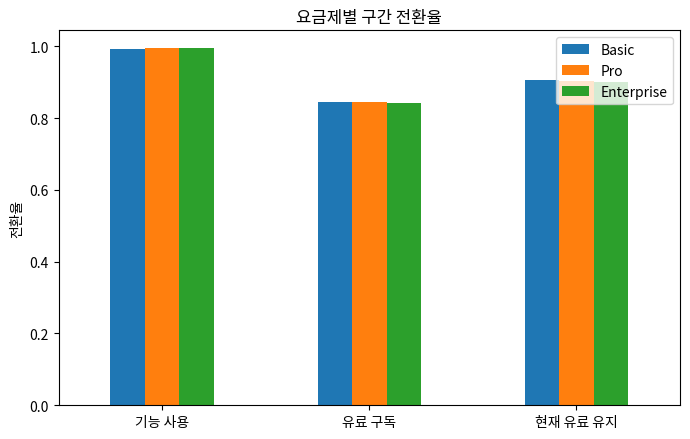

In [ ]:
def calculate_segment_funnel(segment_col, segment_value):
    seg_subs = subscriptions[subscriptions[segment_col] == segment_value]

    started_ids = set(seg_subs['subscription_id'])
    used_ids = (set(feature_usage['subscription_id'].unique())) & started_ids
    trial_false_ids = set(seg_subs.loc[seg_subs['is_trial'] == False, 'subscription_id'])
    paid_ids = used_ids & trial_false_ids
    no_end_ids = set(seg_subs.loc[seg_subs['end_date'].isna(), 'subscription_id'])
    retained_paid_ids = paid_ids & no_end_ids

    counts = [len(started_ids), len(used_ids), len(paid_ids), len(retained_paid_ids)]
    conversion = [None] + [counts[i] / counts[i-1] for i in range(1, 4)]

    return pd.DataFrame({
        'stage': ['구독 시작', '기능 사용', '유료 구독', '현재 유료 유지'],
        'subscriptions': counts,
        'conversion_rate': conversion
    })

plan_funnel = pd.concat(
    {plan: calculate_segment_funnel('plan_tier', plan) for plan in ['Basic', 'Pro', 'Enterprise']},
    names=['plan_tier']
).reset_index(level=0)

print(plan_funnel)

# 첫 단계 빼고 구간 전환율 비교
pivot = plan_funnel[plan_funnel['stage'] != '구독 시작'].pivot(index='stage', columns='plan_tier', values='conversion_rate')
pivot = pivot.loc[['기능 사용', '유료 구독', '현재 유료 유지']]

pivot.plot(kind='bar', figsize=(7,4.5), ylabel='전환율')
plt.title('요금제별 구간 전환율')
plt.tight_layout()
plt.show()


세 요금제 전부 비슷한 패턴이다. **기능 사용 → 유료 구독** 구간에서 다 같이 확 떨어지고(84%대), 그 중에서는 **Enterprise**가 84.13%로 제일 낮다. 그래서 전환율이 가장 낮은 조합은 **Enterprise, 기능 사용 → 유료 구독**이다.

근데 요금제 간 차이는 84.13%~84.57% 정도로 사실 크지 않다. 그래서 "특정 요금제만 유난히 문제다"라기보다는, 이 구간 자체가 Ravenstack 전체의 공통적인 약점인 것 같다. 그래도 Enterprise가 매출 비중이 큰 만큼, 여기서 조금이라도 전환율을 올리면 효과가 클 것 같아서 Enterprise를 우선 점검 대상으로 잡았다.


### 필수 2 답변 작성란

- **Q1.** 전환율이 가장 낮은 조합은 **Enterprise 요금제의 기능 사용 → 유료 구독 구간**(84.13%)이다.
- **Q2.** 전체 퍼널만 보면 "유료 전환 구간이 약하다"까지만 알 수 있는데, 요금제별로 나눠보면 그게 특정 요금제에서 더 심한 건지 전체적으로 비슷한 건지 구분할 수 있다. 그래야 특정 그룹에 조치를 집중할지, 전체 공통 프로세스를 고칠지 판단할 수 있어서 더 유용하다.
- **Q3.** 크지 않은 편이다. 세 요금제 모두 84%대 초반에서 거의 비슷하게 나왔다.
- **Q4.** 요금제별 차이가 크지 않다는 점을 보면 이건 특정 요금제만의 문제가 아니라 공통 문제일 가능성이 있어서, trial 종료 시점의 안내 메일이나 결제 유도 화면, 가격 정책 관련 데이터를 추가로 봐야 할 것 같다.


---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

  billing_frequency      stage  subscriptions  conversion_rate
0           monthly      구독 시작           2539              NaN
1           monthly      기능 사용           2520         0.992516
2           monthly      유료 구독           2120         0.841270
3           monthly  현재 유료 유지           1930         0.910377
0            annual      구독 시작           2461              NaN
1            annual      기능 사용           2447         0.994311
2            annual      유료 구독           2073         0.847364
3            annual  현재 유료 유지           1858         0.896285


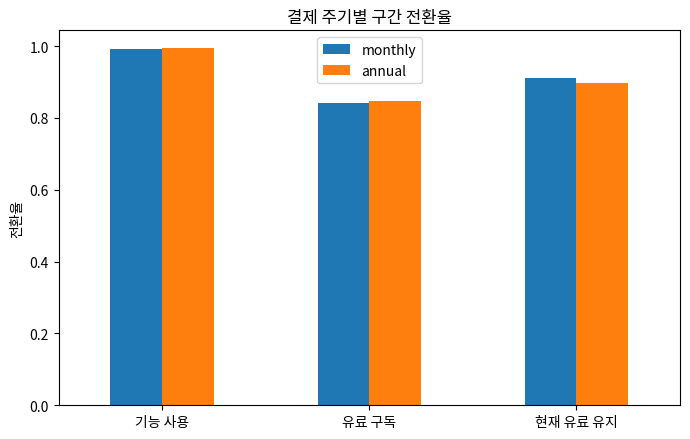

In [ ]:
billing_funnel = pd.concat(
    {bf: calculate_segment_funnel('billing_frequency', bf) for bf in ['monthly', 'annual']},
    names=['billing_frequency']
).reset_index(level=0)

print(billing_funnel)

pivot_b = billing_funnel[billing_funnel['stage'] != '구독 시작'].pivot(index='stage', columns='billing_frequency', values='conversion_rate')
pivot_b = pivot_b.loc[['기능 사용', '유료 구독', '현재 유료 유지']]

pivot_b.plot(kind='bar', figsize=(7,4.5), ylabel='전환율')
plt.title('결제 주기별 구간 전환율')
plt.tight_layout()
plt.show()


전환율이 가장 낮은 조합은 monthly, 기능 사용 → 유료 구독이다. annual은 같은 구간에서 84.74%로 monthly보다 조금 더 높다.

월간 결제 고객은 부담이 적어서 가볍게 써보다가 유료로 안 넘어가는 경우가 많은 게 아닐까 싶은데, 이건 가설일 뿐이고 퍼널 결과만으로 확정할 수는 없다. 실제로는 monthly 고객들의 가격 민감도나 결제 화면 이탈 로그 같은 걸 더 봐야 할 것 같다.


### 과제 1 답변 작성란

- **Q1.** 전환율이 가장 낮은 조합은 monthly 결제 주기의 기능 사용 → 유료 구독 구간이다.
- **Q2.** 이 구간의 전환율은 84.13%, 이탈률은 15.87%다.
- **Q3.** 없다고 생각한다. monthly와 annual의 차이도 1%p 정도로 크지 않고, 결제 주기 말고 다른 요인(가격 민감도, 가입 시기 등)이 영향을 줬을 수도 있어서 이 결과만으로 결제 주기가 원인이라고 말하기는 어렵다.


---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?
2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?
3. 전환율과 이탈률은 어떻게 계산했나요?
4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?
5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?

### 실습 마무리 답변

1. 퍼널은 구독 시작 → 기능 사용 → 유료 구독 → 현재 유료 유지, 이렇게 네 단계로 정의했다.
2. 이벤트(사용 로그) 행 수 대신 **구독 ID의 고유 개수**를 사용했다. 같은 구독이 여러 번 기능을 써도 한 번만 세야 정확한 퍼널이 되기 때문이다.
3. 전환율은 현재 단계 구독 수 ÷ 이전 단계 구독 수로 계산했고, 이탈률은 1 - 전환율로 계산했다.
4. 전체 퍼널에서 제일 문제였던 구간은 **기능 사용 → 유료 구독** 구간이었다. 여기서 전환율이 84% 정도로 가장 낮고 빠지는 구독 수도 제일 많았다.
5. 퍼널 분석 결과는 "어디서 많이 빠지는가"만 보여줄 뿐 "왜 빠지는가"는 알려주지 않기 때문에, 실제 원인을 알려면 추가 데이터(설문, 가격 정책, 사용자 인터뷰 등)를 확인해야 한다. 낮은 전환율을 곧바로 원인으로 단정하면 잘못된 결론을 내릴 수 있어서 이 둘을 구분해야 한다고 생각한다.
